In [2384]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nonameexi/heart-csv/heart.csv


In [2385]:
import os
path=    "/kaggle/input/datasets/nonameexi/heart-csv"
print(os.listdir(path))

['heart.csv']


In [2386]:
import pandas as pd
df=pd.read_csv("/kaggle/input/datasets/nonameexi/heart-csv/heart.csv")

In [2387]:
df.duplicated().sum()

np.int64(0)

In [2388]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [2389]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


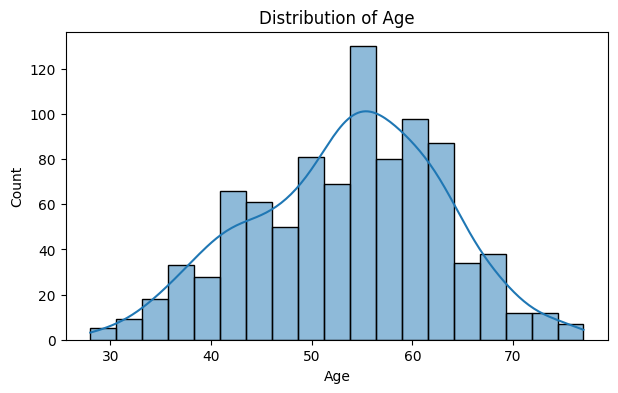

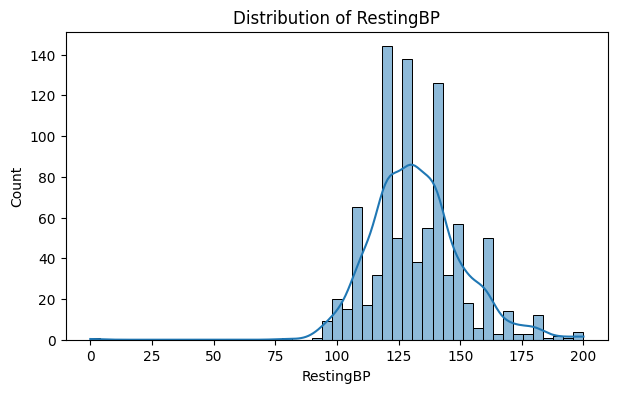

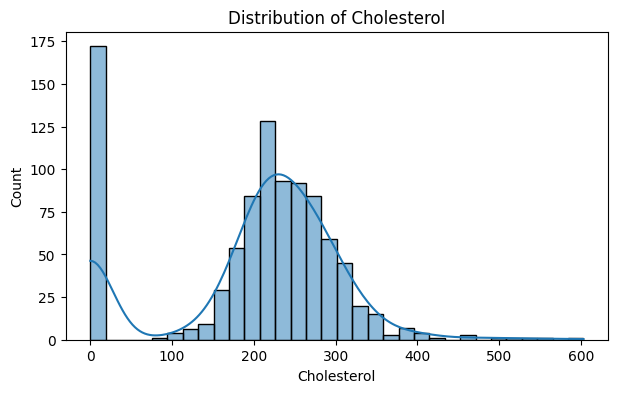

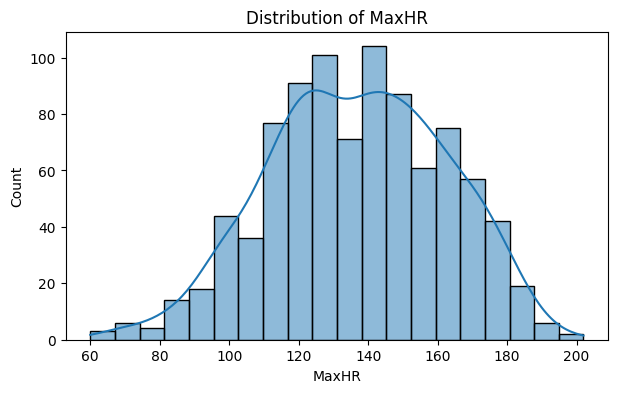

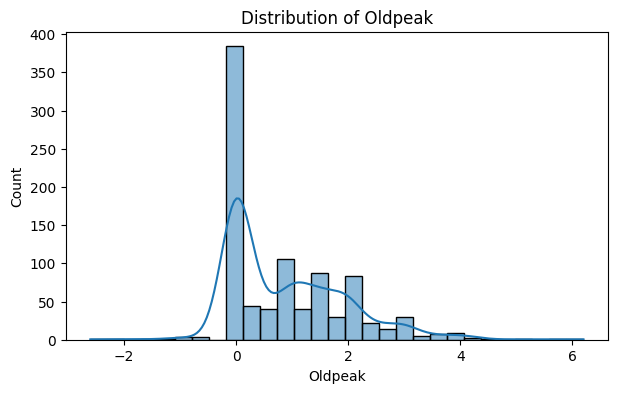

In [2390]:
import matplotlib.pyplot as plt
import seaborn as sns
n_col=["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]
for col in n_col:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

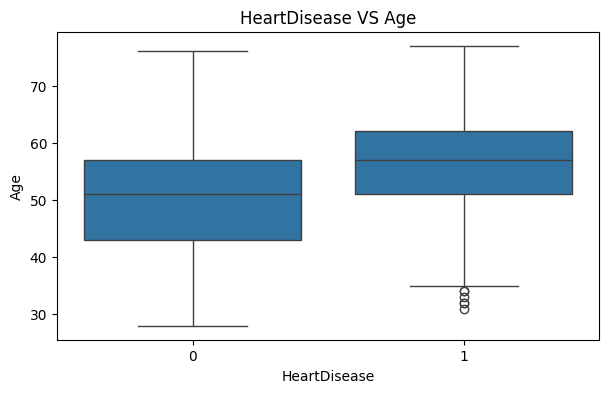

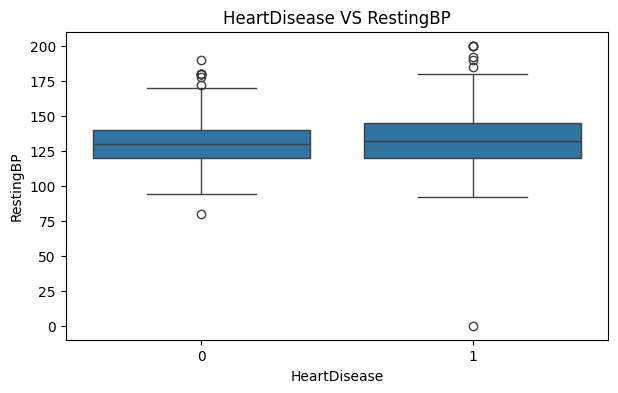

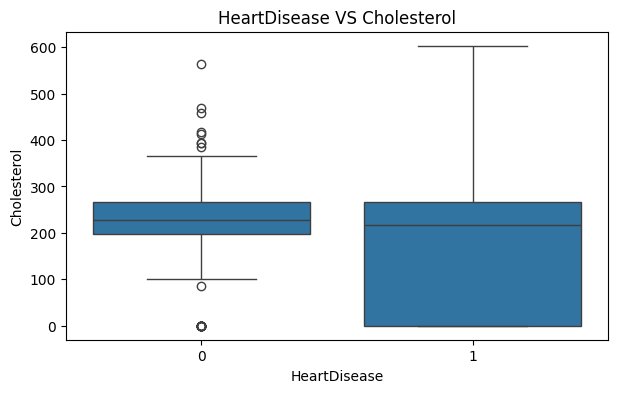

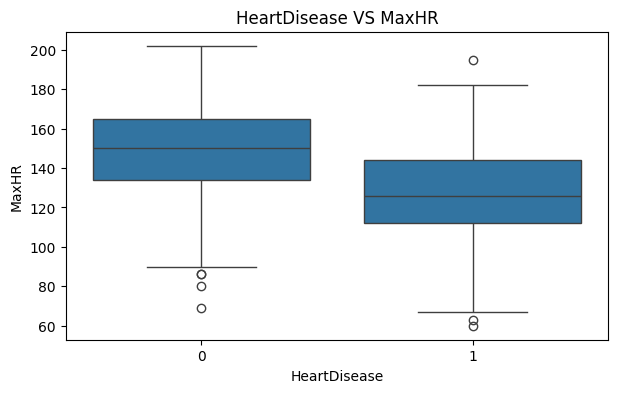

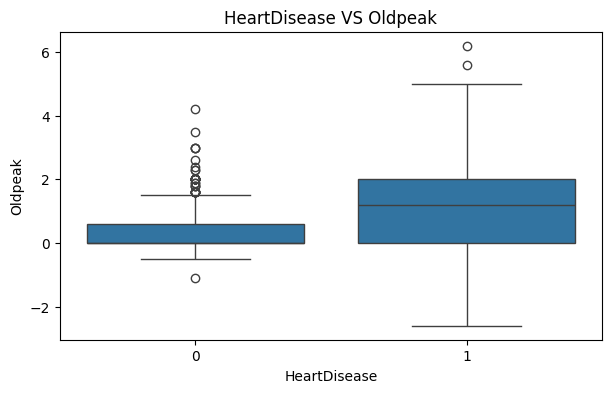

In [2391]:
import matplotlib.pyplot as plt
import seaborn as sns
n_col=["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]
for col in n_col:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df,x="HeartDisease",y=col)
    plt.title(f"HeartDisease VS {col}")
    plt.xlabel("HeartDisease")
    plt.ylabel(col)
    plt.show()

In [2392]:
(df["RestingBP"]==0).sum()


np.int64(1)

In [2393]:
median_Rest=df.loc[df["RestingBP"]!=0,"RestingBP"].median()
df.loc[df["RestingBP"]==0,"RestingBP"]=median_Rest
(df["RestingBP"]==0).sum()

np.int64(0)

In [2394]:
chol_zero=df[df["Cholesterol"]==0]
chol_zero

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


In [2395]:
chol_zero["Sex"].value_counts()

Sex
M    161
F     11
Name: count, dtype: int64

In [2396]:
chol_zero = df[df["Cholesterol"] == 0]

chol_zero[[
    "Age",
    "Sex",
    "ChestPainType",
    "RestingBP",
    "FastingBS",
    "RestingECG",
    "MaxHR",
    "ExerciseAngina",
    "Oldpeak",
    "ST_Slope",
    "HeartDisease"
]].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,172.0,NaN,NaN,NaN,56.238372,8.616327,32.0,51.75,57.5,62.0,74.0
Sex,172,2,M,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,172,4,ASY,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,172.0,NaN,NaN,NaN,130.436047,20.706851,80.0,115.0,130.0,140.0,200.0
FastingBS,172.0,NaN,NaN,NaN,0.517442,0.501155,0.0,0.0,1.0,1.0,1.0
RestingECG,172,3,Normal,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,172.0,NaN,NaN,NaN,121.988372,24.166331,60.0,108.0,120.0,138.25,182.0
ExerciseAngina,172,2,N,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,172.0,NaN,NaN,NaN,0.825581,1.039645,-2.6,0.0,0.75,1.5,3.7
ST_Slope,172,3,Flat,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2397]:
pd.crosstab(
    chol_zero["Sex"],
    chol_zero["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
Sex,,
F,9.090909,90.909091
M,11.801242,88.198758


In [2398]:
valid_chol=df[df["Cholesterol"]!=0]
print("zeros", len(chol_zero))
print("non-zeros",len(valid_chol))

zeros 172
non-zeros 746


In [2399]:
valid_chol["HeartDisease"].value_counts()

HeartDisease
0    390
1    356
Name: count, dtype: int64

In [2400]:
df["Cholesterol_missing"]=(df["Cholesterol"]==0).astype(int)

In [2401]:
df["Cholesterol_missing"]

0      0
1      0
2      0
3      0
4      0
      ..
913    0
914    0
915    0
916    0
917    0
Name: Cholesterol_missing, Length: 918, dtype: int64

In [2402]:
compare_cols = ["Age", "RestingBP", "MaxHR", "Oldpeak"]

pd.DataFrame({
    "Cholesterol = 0": chol_zero[compare_cols].median(),
    "Cholesterol > 0": valid_chol[compare_cols].median()
})

,Cholesterol = 0,Cholesterol > 0
Age,57.50,54.0
RestingBP,130.00,130.0
MaxHR,120.00,140.0
Oldpeak,0.75,0.5


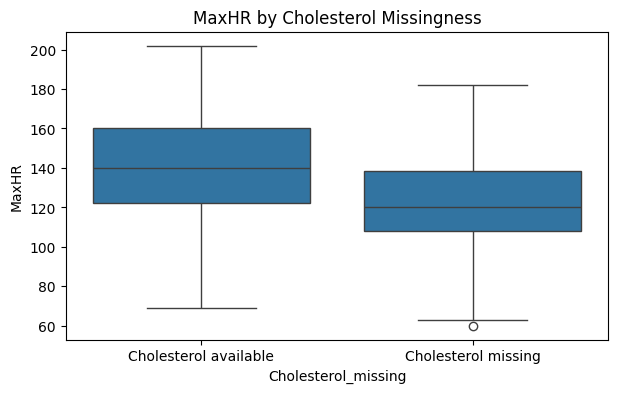

In [2403]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Cholesterol_missing",
    y="MaxHR"
)

plt.xticks(
    [0, 1],
    ["Cholesterol available", "Cholesterol missing"]
)

plt.title("MaxHR by Cholesterol Missingness")
plt.show()

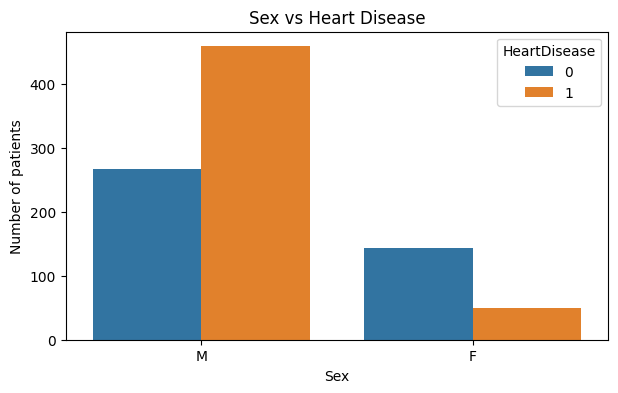

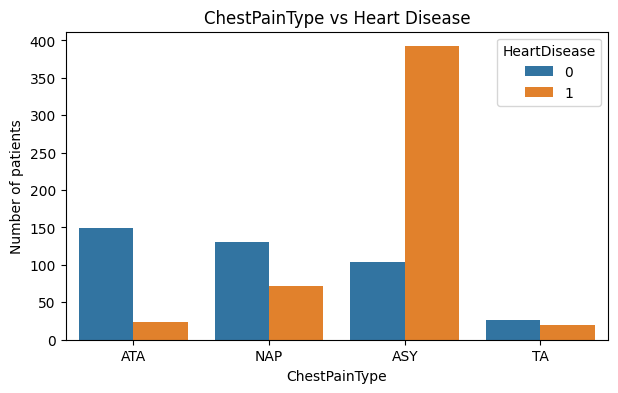

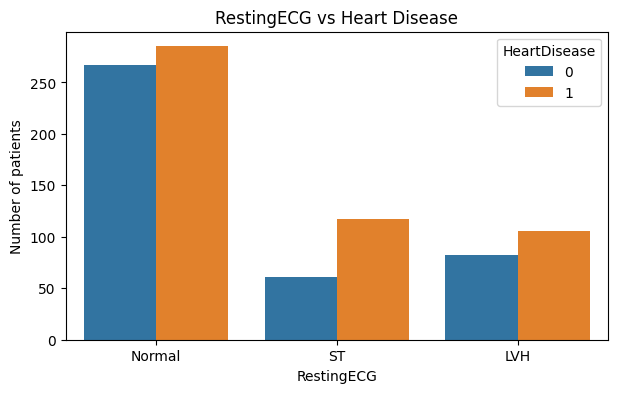

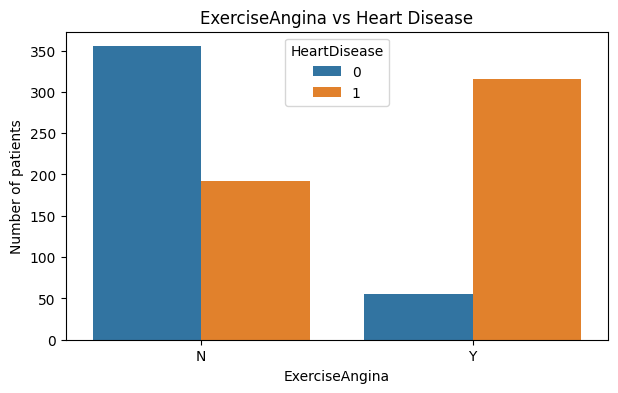

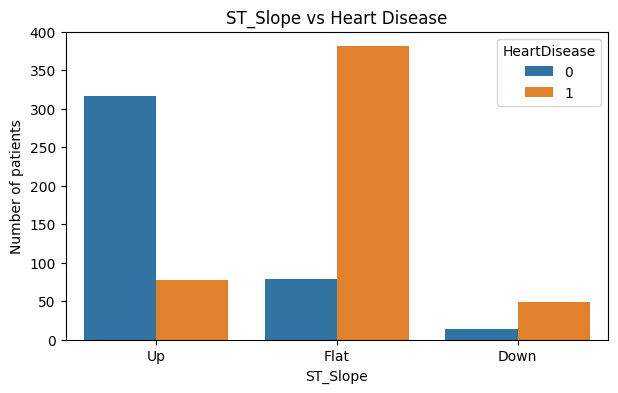

In [2404]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(
        data=df,
        x=col,
        hue="HeartDisease"
    )
    plt.title(f"{col} vs Heart Disease")
    plt.xlabel(col)
    plt.ylabel("Number of patients")
    plt.show()

In [2405]:
for col in [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]:
    
    print("\n==============================")
    print(col)
    print("==============================")
    
    result = pd.crosstab(
        df[col],
        df["HeartDisease"],
        normalize="index"
    ) * 100
    
    print(result.round(2))


Sex
HeartDisease      0      1
Sex                       
F             74.09  25.91
M             36.83  63.17

ChestPainType
HeartDisease       0      1
ChestPainType              
ASY            20.97  79.03
ATA            86.13  13.87
NAP            64.53  35.47
TA             56.52  43.48

RestingECG
HeartDisease      0      1
RestingECG                
LVH           43.62  56.38
Normal        48.37  51.63
ST            34.27  65.73

ExerciseAngina
HeartDisease        0      1
ExerciseAngina              
N               64.90  35.10
Y               14.82  85.18

ST_Slope
HeartDisease      0      1
ST_Slope                  
Down          22.22  77.78
Flat          17.17  82.83
Up            80.25  19.75


In [2406]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Cholesterol_missing
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,0
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,0


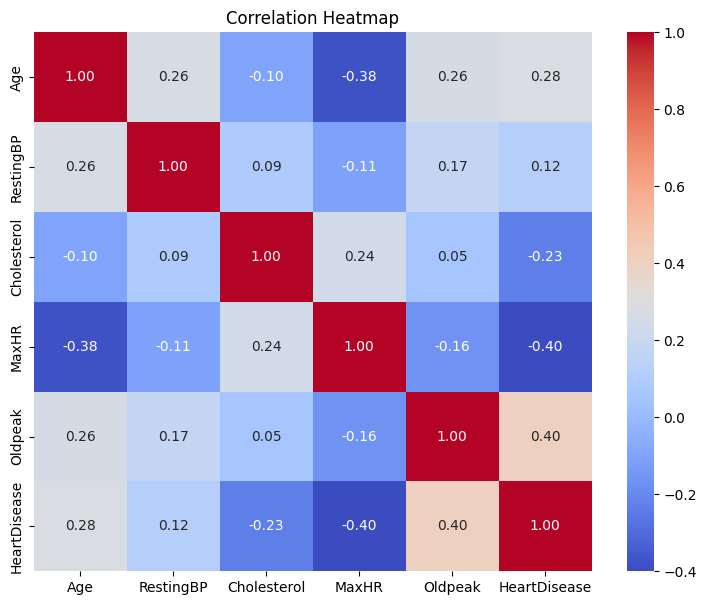

In [2407]:
n_colm =["Age","RestingBP","Cholesterol","MaxHR","Oldpeak","HeartDisease"]
plt.figure(figsize=(9,7))
sns.heatmap(
    df[n_colm].corr()
,    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [2408]:
from scipy.stats import chi2_contingency
import numpy as np

cat_cols = [
    "Age",
    "Oldpeak",
    "ChestPainType",
    "ST_Slope",
    "FastingBS",
    "MaxHR",
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
    
]

for col in cat_cols:
    table = pd.crosstab(df[col], df["HeartDisease"])

    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape

    cramers_v = np.sqrt(
        (chi2 / n) / min(k - 1, r - 1)
    )

    print(f"{col}: {cramers_v:.3f}")

Age: 0.370
Oldpeak: 0.501
ChestPainType: 0.540
ST_Slope: 0.623
FastingBS: 0.265
MaxHR: 0.513
Sex: 0.303
ChestPainType: 0.540
RestingECG: 0.109
ExerciseAngina: 0.492
ST_Slope: 0.623


In [2409]:
valid_chol = df[df["Cholesterol"] != 0]

print(
    "Valid cholesterol correlation:",
    valid_chol["Cholesterol"].corr(valid_chol["HeartDisease"])
)

Valid cholesterol correlation: 0.10386559562465641


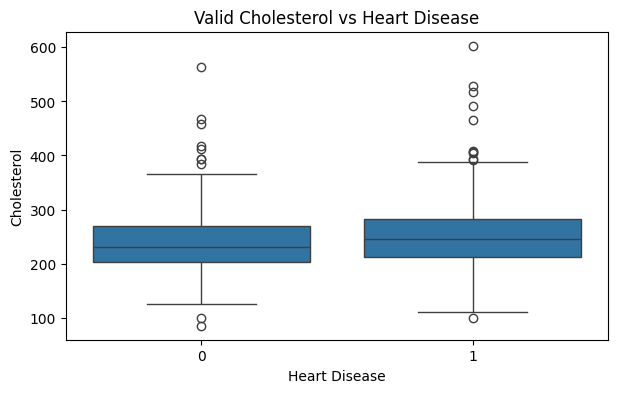

In [2410]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=valid_chol,
    x="HeartDisease",
    y="Cholesterol"
)

plt.title("Valid Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")

plt.show()

In [2411]:
print(df.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'Cholesterol_missing']


In [2412]:
X=df.drop("HeartDisease",axis=1)
y=df["HeartDisease"]

X.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Cholesterol_missing
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,0
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2413]:
cat_features=["Sex","ChestPainType","FastingBS","RestingECG","ExerciseAngina","ST_Slope","Cholesterol_missing"]
num_features=["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]

In [2414]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    random_state=42,
    test_size=0.2,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(734, 12)
(184, 12)


In [2415]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [2416]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=15))
])

In [2417]:
knn_pipeline.fit(X_train, y_train)

y_pred = knn_pipeline.predict(X_test)

In [2418]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("KNN")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

KNN
Accuracy : 0.907608695652174
Precision: 0.9047619047619048
Recall   : 0.9313725490196079
F1 Score : 0.9178743961352657


In [2419]:
cat_features_no_ecg=["Sex","ChestPainType","FastingBS","ExerciseAngina","ST_Slope","Cholesterol_missing"]
num_features_no_ecg=["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]

In [2420]:
preprocessor_no_ecg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_no_ecg),
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         cat_features_no_ecg)
    ]
)

In [2421]:
knn_no_ecg = Pipeline([
    ("preprocessor", preprocessor_no_ecg),
    ("knn", KNeighborsClassifier(n_neighbors=15))
])

In [2422]:
knn_no_ecg.fit(X_train, y_train)

y_pred_no_ecg = knn_no_ecg.predict(X_test)

print("KNN without RestingECG")
print("Accuracy :", accuracy_score(y_test, y_pred_no_ecg))
print("Precision:", precision_score(y_test, y_pred_no_ecg))
print("Recall   :", recall_score(y_test, y_pred_no_ecg))
print("F1 Score :", f1_score(y_test, y_pred_no_ecg))

KNN without RestingECG
Accuracy : 0.9130434782608695
Precision: 0.9134615384615384
Recall   : 0.9313725490196079
F1 Score : 0.9223300970873787


In [2423]:
cat_features_no_ecg_bp=["Sex","ChestPainType","FastingBS","ExerciseAngina","ST_Slope","Cholesterol_missing"]
num_features_no_ecg_bp=["Age","Cholesterol","MaxHR","Oldpeak"]

In [2424]:
preprocessor_no_ecg_bp = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_no_ecg_bp),
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         cat_features_no_ecg_bp)
    ]
)

In [2425]:
knn_no_ecg_bp = Pipeline([
    ("preprocessor", preprocessor_no_ecg_bp),
    ("knn", KNeighborsClassifier(n_neighbors=15))
])

In [2426]:
knn_no_ecg_bp.fit(X_train, y_train)

y_pred_no_ecg_bp = knn_no_ecg_bp.predict(X_test)

print("KNN without RestingECG + RestingBP")
print("Accuracy :", accuracy_score(y_test, y_pred_no_ecg_bp))
print("Precision:", precision_score(y_test, y_pred_no_ecg_bp))
print("Recall   :", recall_score(y_test, y_pred_no_ecg_bp))
print("F1 Score :", f1_score(y_test, y_pred_no_ecg_bp))

KNN without RestingECG + RestingBP
Accuracy : 0.9021739130434783
Precision: 0.8962264150943396
Recall   : 0.9313725490196079
F1 Score : 0.9134615384615384


In [2427]:
from sklearn.impute import SimpleImputer

In [2428]:
num_features_chol = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

In [2429]:
cat_features_chol = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "ExerciseAngina",
    "ST_Slope",
    "Cholesterol_missing"
]

In [2430]:
preprocessor_chol = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(
                    missing_values=0,
                    strategy="median"
                )),
                ("scaler", StandardScaler())
            ]),
            num_features_chol
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_features_chol
        )
    ]
)

In [2431]:
knn_chol = Pipeline([
    ("preprocessor", preprocessor_chol),
    ("knn", KNeighborsClassifier(n_neighbors=15))
])

In [2432]:
knn_chol.fit(X_train, y_train)

y_pred_chol = knn_chol.predict(X_test)

In [2433]:
print("KNN - Median Cholesterol + Missing Indicator")

print("Accuracy :",
      accuracy_score(y_test, y_pred_chol))

print("Precision:",
      precision_score(y_test, y_pred_chol))

print("Recall   :",
      recall_score(y_test, y_pred_chol))

print("F1 Score :",
      f1_score(y_test, y_pred_chol))

KNN - Median Cholesterol + Missing Indicator
Accuracy : 0.8913043478260869
Precision: 0.8942307692307693
Recall   : 0.9117647058823529
F1 Score : 0.9029126213592233


In [2434]:
cat_features_no_chol = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "ExerciseAngina",
    "ST_Slope"
]

num_features_no_chol = [
    "Age",
    "RestingBP",
    "MaxHR",
    "Oldpeak"
]
preprocessor_no_chol = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_features_no_chol
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_features_no_chol
        )
    ]
)
knn_no_chol = Pipeline([
    ("preprocessor", preprocessor_no_chol),
    ("knn", KNeighborsClassifier(n_neighbors=15))
])
knn_no_chol.fit(X_train, y_train)

y_pred_no_chol = knn_no_chol.predict(X_test)

print("KNN - No RestingECG + No Cholesterol")

print("Accuracy :",
      accuracy_score(y_test, y_pred_no_chol))

print("Precision:",
      precision_score(y_test, y_pred_no_chol))

print("Recall   :",
      recall_score(y_test, y_pred_no_chol))

print("F1 Score :",
      f1_score(y_test, y_pred_no_chol))

KNN - No RestingECG + No Cholesterol
Accuracy : 0.9130434782608695
Precision: 0.9134615384615384
Recall   : 0.9313725490196079
F1 Score : 0.9223300970873787


In [2435]:
cat_features_no_fbs = [
    "Sex",
    "ChestPainType",
    "ExerciseAngina",
    "ST_Slope"
]

num_features_no_fbs = [
    "Age",
    "RestingBP",
    "MaxHR",
    "Oldpeak"
]

In [2436]:
preprocessor_no_fbs = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_features_no_fbs
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_features_no_fbs
        )
    ]
)

In [2437]:
knn_no_fbs = Pipeline([
    ("preprocessor", preprocessor_no_fbs),
    ("knn", KNeighborsClassifier(n_neighbors=15))
])

In [2438]:
knn_no_fbs.fit(X_train, y_train)

y_pred_no_fbs = knn_no_fbs.predict(X_test)

print("KNN - No RestingECG + No Cholesterol + No FastingBS")

print("Accuracy :",
      accuracy_score(y_test, y_pred_no_fbs))

print("Precision:",
      precision_score(y_test, y_pred_no_fbs))

print("Recall   :",
      recall_score(y_test, y_pred_no_fbs))

print("F1 Score :",
      f1_score(y_test, y_pred_no_fbs))

KNN - No RestingECG + No Cholesterol + No FastingBS
Accuracy : 0.8967391304347826
Precision: 0.9108910891089109
Recall   : 0.9019607843137255
F1 Score : 0.9064039408866995


In [2439]:
categorical_features_final = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "ExerciseAngina",
    "ST_Slope"
]

numerical_features_final = [
    "Age",
    "RestingBP",
    "MaxHR",
    "Oldpeak"
]

In [2440]:
preprocessor_final = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_final
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_final
        )
    ]
)

In [2441]:
knn_final = Pipeline([
    ("preprocessor", preprocessor_final),
    ("knn", KNeighborsClassifier(n_neighbors=15))
])

In [2442]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    knn_final,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("KNN CV scores:", cv_scores)
print("KNN CV average:", cv_scores.mean())

KNN CV scores: [0.9076087  0.85869565 0.83152174 0.87978142 0.86338798]
KNN CV average: 0.868199097172725


In [2443]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

k_results = []

for k in range(1, 31):
    
    model = Pipeline([
        ("preprocessor", preprocessor_final),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )
    
    k_results.append((k, scores.mean()))
    
    print(k, round(scores.mean() * 100, 2))

1 80.61
2 79.19
3 84.97
4 83.99
5 85.62
6 85.19
7 85.41
8 85.41
9 86.28
10 85.41
11 86.6
12 86.39
13 86.39
14 86.17
15 86.82
16 86.71
17 86.6
18 86.17
19 86.49
20 86.39
21 86.6
22 86.71
23 86.6
24 86.5
25 86.71
26 86.6
27 86.71
28 86.82
29 86.39
30 87.15


In [2444]:
best_k, best_score = max(k_results, key=lambda x: x[1])

print("\nBest K:", best_k)
print("Best CV accuracy:", best_score)


Best K: 30
Best CV accuracy: 0.8714837253504395


In [2445]:
from sklearn.linear_model import LogisticRegression

lr_final = Pipeline([
    ("preprocessor", preprocessor_final),
    ("lr", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_cv_scores = cross_val_score(
    lr_final,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("LR CV scores:", lr_cv_scores)
print("LR CV average:", lr_cv_scores.mean())

LR CV scores: [0.86956522 0.85869565 0.83152174 0.89617486 0.8579235 ]
LR CV average: 0.862776193870278


In [2446]:
from sklearn.model_selection import GridSearchCV

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor_final),
    ("lr", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

param_grid = {
    "lr__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l2"]
}

grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X, y)

print("Best parameters:", grid_lr.best_params_)
print("Best CV accuracy:", grid_lr.best_score_)

Best parameters: {'lr__C': 1, 'lr__penalty': 'l2'}
Best CV accuracy: 0.862776193870278


In [2447]:
from sklearn.model_selection import cross_validate

knn_30 = Pipeline([
    ("preprocessor", preprocessor_final),
    ("knn", KNeighborsClassifier(n_neighbors=30))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    knn_30,
    X,
    y,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric}: {scores}")
    print(f"{metric} average: {scores.mean():.4f}")

accuracy: [0.9076087  0.8423913  0.8423913  0.90163934 0.86338798]
accuracy average: 0.8715
precision: [0.93814433 0.86868687 0.85436893 0.88073394 0.83928571]
precision average: 0.8762
recall: [0.89215686 0.84313725 0.8627451  0.95049505 0.93069307]
recall average: 0.8958
f1: [0.91457286 0.85572139 0.85853659 0.91428571 0.88262911]
f1 average: 0.8851
roc_auc: [0.95277379 0.93346485 0.8863582  0.94542381 0.90799324]
roc_auc average: 0.9252


In [2448]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features_tree = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "ExerciseAngina",
    "ST_Slope"
]

numerical_features_tree = [
    "Age",
    "RestingBP",
    "MaxHR",
    "Oldpeak"
]

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features_tree
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_tree
        )
    ]
)

In [2449]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("dt", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

In [2450]:
dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Decision Tree
Accuracy : 0.7880434782608695
Precision: 0.8118811881188119
Recall   : 0.803921568627451
F1 Score : 0.8078817733990148


In [2451]:
dt_cv_scores = cross_val_score(
    dt_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("DT CV scores:", dt_cv_scores)
print("DT CV average:", dt_cv_scores.mean())

DT CV scores: [0.86956522 0.79891304 0.78804348 0.82513661 0.82513661]
DT CV average: 0.82135899263483


In [2452]:
from sklearn.ensemble import RandomForestClassifier

In [2453]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_final),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [2454]:
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest
Accuracy : 0.8641304347826086
Precision: 0.8737864077669902
Recall   : 0.8823529411764706
F1 Score : 0.8780487804878049


In [2455]:
rf_cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("RF CV scores:", rf_cv_scores)
print("RF CV average:", rf_cv_scores.mean())

RF CV scores: [0.9076087  0.85869565 0.80434783 0.8852459  0.84153005]
RF CV average: 0.8594856260394395


In [2456]:
from sklearn.svm import SVC

In [2457]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor_final),
    ("svm", SVC(
        kernel="rbf",
        C=1,
        gamma="scale"
    ))
])

In [2458]:
svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)

print("SVM")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

SVM
Accuracy : 0.875
Precision: 0.8691588785046729
Recall   : 0.9117647058823529
F1 Score : 0.8899521531100478


In [2459]:
svm_cv_scores = cross_val_score(
    svm_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("SVM CV scores:", svm_cv_scores)
print("SVM CV average:", svm_cv_scores.mean())

SVM CV scores: [0.9076087  0.86413043 0.82065217 0.86338798 0.85245902]
SVM CV average: 0.861647659776669


In [2460]:


from sklearn.naive_bayes import GaussianNB

In [2461]:
preprocessor_nb = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_final
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_final
        )
    ]
)

In [2462]:
nb_pipeline = Pipeline([
    ("preprocessor", preprocessor_nb),
    ("nb", GaussianNB())
])

In [2463]:
nb_cv_scores = cross_val_score(
    nb_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Naive Bayes CV scores:", nb_cv_scores)
print("Naive Bayes CV average:", nb_cv_scores.mean())

Naive Bayes CV scores: [0.86956522 0.8423913  0.82065217 0.87978142 0.85245902]
Naive Bayes CV average: 0.8529698265621286


In [2464]:
k_results_extended = []

for k in range(31, 61):

    model = Pipeline([
        ("preprocessor", preprocessor_final),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    k_results_extended.append((k, scores.mean()))

    print(f"K={k:2d}  CV={scores.mean()*100:.2f}%")

best_extended = max(
    k_results_extended,
    key=lambda x: x[1]
)

print("\nBest K from 31-60:", best_extended[0])
print("Best CV:", best_extended[1])

K=31  CV=86.49%
K=32  CV=87.04%
K=33  CV=86.49%
K=34  CV=87.15%
K=35  CV=86.82%
K=36  CV=86.49%
K=37  CV=86.49%
K=38  CV=86.28%
K=39  CV=86.06%
K=40  CV=86.28%
K=41  CV=86.28%
K=42  CV=86.28%
K=43  CV=86.38%
K=44  CV=85.84%
K=45  CV=86.06%
K=46  CV=85.84%
K=47  CV=85.95%
K=48  CV=85.84%
K=49  CV=85.95%
K=50  CV=85.84%
K=51  CV=85.84%
K=52  CV=85.84%
K=53  CV=85.62%
K=54  CV=85.73%
K=55  CV=85.62%
K=56  CV=85.84%
K=57  CV=85.62%
K=58  CV=85.62%
K=59  CV=85.62%
K=60  CV=85.73%

Best K from 31-60: 34
Best CV: 0.8714777856973152


In [2465]:
from sklearn.model_selection import GridSearchCV

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor_final),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": range(5, 51),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

grid_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X, y)

print("Best parameters:", grid_knn.best_params_)
print("Best CV accuracy:", grid_knn.best_score_)

Best parameters: {'knn__n_neighbors': 17, 'knn__p': 1, 'knn__weights': 'uniform'}
Best CV accuracy: 0.8769125683060108


In [2466]:
best_knn = grid_knn.best_estimator_

y_pred_best = best_knn.predict(X_test)

print("Best KNN")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

Best KNN
Accuracy : 0.907608695652174
Precision: 0.912621359223301
Recall   : 0.9215686274509803
F1 Score : 0.9170731707317074


In [2467]:
from sklearn.metrics import roc_auc_score

y_prob_best = best_knn.predict_proba(X_test)[:, 1]

print("ROC-AUC   :", roc_auc_score(y_test, y_prob_best))

ROC-AUC   : 0.9551649928263989


In [2468]:
from sklearn.model_selection import cross_validate

best_knn = grid_knn.best_estimator_

final_cv_results = cross_validate(
    best_knn,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = final_cv_results[f"test_{metric}"]

    print(f"{metric}: {scores}")
    print(f"{metric} average: {scores.mean():.4f}")
    print()

accuracy: [0.91304348 0.86956522 0.8423913  0.8852459  0.87431694]
accuracy average: 0.8769

precision: [0.94791667 0.89795918 0.84761905 0.87735849 0.84821429]
precision average: 0.8838

recall: [0.89215686 0.8627451  0.87254902 0.92079208 0.94059406]
recall average: 0.8978

f1: [0.91919192 0.88       0.85990338 0.89855072 0.89201878]
f1 average: 0.8899

roc_auc: [0.94811095 0.93663319 0.89329268 0.94421637 0.90763101]
roc_auc average: 0.9260



In [2469]:
from sklearn.ensemble import BaggingClassifier

In [2470]:
bagging_knn = Pipeline([
    ("preprocessor", preprocessor_final),
    ("bagging", BaggingClassifier(
        estimator=KNeighborsClassifier(
            n_neighbors=17,
            weights="uniform",
            p=1
        ),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [2471]:
bagging_cv = cross_val_score(
    bagging_knn,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Bagging CV scores:", bagging_cv)
print("Bagging CV average:", bagging_cv.mean())

Bagging CV scores: [0.9076087  0.86956522 0.83152174 0.87978142 0.86885246]
Bagging CV average: 0.8714659063910668


In [2472]:
from sklearn.ensemble import StackingClassifier

In [2473]:
knn_base = Pipeline([
    ("preprocessor", preprocessor_final),
    ("knn", KNeighborsClassifier(
        n_neighbors=17,
        weights="uniform",
        p=1
    ))
])

lr_base = Pipeline([
    ("preprocessor", preprocessor_final),
    ("lr", LogisticRegression(
        C=1,
        max_iter=2000,
        random_state=42
    ))
])

rf_base = Pipeline([
    ("preprocessor", preprocessor_final),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [2474]:
stacking_model = StackingClassifier(
    estimators=[
        ("knn", knn_base),
        ("lr", lr_base),
        ("rf", rf_base)
    ],
    final_estimator=LogisticRegression(
        max_iter=2000
    ),
    cv=5,
    n_jobs=-1
)

In [2475]:
stacking_cv = cross_val_score(
    stacking_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Stacking CV scores:", stacking_cv)
print("Stacking CV average:", stacking_cv.mean())

Stacking CV scores: [0.90217391 0.875      0.82065217 0.89071038 0.86338798]
Stacking CV average: 0.8703848895224517


In [2476]:
from sklearn.ensemble import GradientBoostingClassifier

In [2477]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor_final),
    ("gb", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [2478]:
gb_cv_scores = cross_val_score(
    gb_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Gradient Boosting CV scores:", gb_cv_scores)
print("Gradient Boosting CV average:", gb_cv_scores.mean())

Gradient Boosting CV scores: [0.9076087  0.8423913  0.81521739 0.87431694 0.83606557]
Gradient Boosting CV average: 0.85511998099311


In [2479]:
print("X columns:")
print(X.columns.tolist())

print("\nFeatures used by model:")
print(numerical_features_final + categorical_features_final)

X columns:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'Cholesterol_missing']

Features used by model:
['Age', 'RestingBP', 'MaxHR', 'Oldpeak', 'Sex', 'ChestPainType', 'FastingBS', 'ExerciseAngina', 'ST_Slope']


In [2480]:
print("X columns:")
print(X.columns.tolist())

X columns:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'Cholesterol_missing']


In [2481]:
selected_features = [
    "Age",
    "Sex",
    "ChestPainType",
    "RestingBP",
    "FastingBS",
    "MaxHR",
    "ExerciseAngina",
    "Oldpeak",
    "ST_Slope"
]

X_selected = df[selected_features]
y = df["HeartDisease"]

In [2482]:
print(X_selected.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [2483]:
X_selected.head(20)

,Age,Sex,ChestPainType,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,0,172,N,0.0,Up
1,49,F,NAP,160,0,156,N,1.0,Flat
2,37,M,ATA,130,0,98,N,0.0,Up
3,48,F,ASY,138,0,108,Y,1.5,Flat
4,54,M,NAP,150,0,122,N,0.0,Up
5,39,M,NAP,120,0,170,N,0.0,Up
6,45,F,ATA,130,0,170,N,0.0,Up
7,54,M,ATA,110,0,142,N,0.0,Up
8,37,M,ASY,140,0,130,Y,1.5,Flat
9,48,F,ATA,120,0,120,N,0.0,Up


In [2484]:
Xnew=pd.get_dummies(X_selected)

In [2485]:
Xnew.astype(int)
print(Xnew.head())

   Age  RestingBP  FastingBS  MaxHR  Oldpeak  Sex_F  Sex_M  ChestPainType_ASY  \
0   40        140          0    172      0.0  False   True              False   
1   49        160          0    156      1.0   True  False              False   
2   37        130          0     98      0.0  False   True              False   
3   48        138          0    108      1.5   True  False               True   
4   54        150          0    122      0.0  False   True              False   

   ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  ExerciseAngina_N  \
0               True              False             False              True   
1              False               True             False              True   
2               True              False             False              True   
3              False              False             False             False   
4              False               True             False              True   

   ExerciseAngina_Y  ST_Slope_Down  ST

In [2486]:
X_encoded = pd.get_dummies(
    X_selected,
    columns=[
        "Sex",
        "ChestPainType",
        "FastingBS",
        "ExerciseAngina",
        "ST_Slope"
    ],
    dtype=int
)
X_encoded.head()

,Age,RestingBP,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,FastingBS_0,FastingBS_1,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,172,0.0,0,1,0,1,0,0,1,0,1,0,0,0,1
1,49,160,156,1.0,1,0,0,0,1,0,1,0,1,0,0,1,0
2,37,130,98,0.0,0,1,0,1,0,0,1,0,1,0,0,0,1
3,48,138,108,1.5,1,0,1,0,0,0,1,0,0,1,0,1,0
4,54,150,122,0.0,0,1,0,0,1,0,1,0,1,0,0,0,1


In [2487]:
X_encoded.shape

(918, 17)

In [2488]:
from sklearn.model_selection import train_test_split

X_train_enc, X_test_enc, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [2489]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    "Age",
    "RestingBP",
    "MaxHR",
    "Oldpeak"
]

scaler = StandardScaler()

X_train_enc = X_train_enc.copy()
X_test_enc = X_test_enc.copy()

X_train_enc[numeric_cols] = scaler.fit_transform(
    X_train_enc[numeric_cols]
)

X_test_enc[numeric_cols] = scaler.transform(
    X_test_enc[numeric_cols]
)

In [2490]:
from sklearn.neighbors import KNeighborsClassifier

knn_final = KNeighborsClassifier(
    n_neighbors=17,
    weights="uniform",
    p=1
)

knn_final.fit(X_train_enc, y_train)

KNeighborsClassifier(n_neighbors=17, p=1)

In [2491]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = knn_final.predict(X_test_enc)
y_prob = knn_final.predict_proba(X_test_enc)[:, 1]

print("KNN - 17 Features")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

KNN - 17 Features
Accuracy : 0.8967391304347826
Precision: 0.9108910891089109
Recall   : 0.9019607843137255
F1 Score : 0.9064039408866995
ROC-AUC  : 0.9394428503108561


In [2492]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

numeric_indices = [0, 1, 2, 3]

knn_encoded = Pipeline([
    (
        "scaler",
        ColumnTransformer(
            transformers=[
                (
                    "num",
                    StandardScaler(),
                    numeric_indices
                )
            ],
            remainder="passthrough"
        )
    ),
    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=17,
            weights="uniform",
            p=1
        )
    )
])

In [2493]:
from sklearn.compose import ColumnTransformer

In [2494]:
cv_encoded = cross_val_score(
    knn_encoded,
    X_encoded,
    y,
    cv=cv,
    scoring="accuracy"
)

print("KNN - 17 encoded features CV scores:", cv_encoded)
print("KNN - 17 encoded features CV average:", cv_encoded.mean())

KNN - 17 encoded features CV scores: [0.91304348 0.86956522 0.8423913  0.8852459  0.87431694]
KNN - 17 encoded features CV average: 0.8769125683060108


In [2495]:
from sklearn.model_selection import cross_validate

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_encoded_results = cross_validate(
    knn_encoded,
    X_encoded,
    y,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores = cv_encoded_results[f"test_{metric}"]

    print(f"{metric}: {scores}")
    print(f"{metric} average: {scores.mean():.4f}")
    print()

accuracy: [0.91304348 0.86956522 0.8423913  0.8852459  0.87431694]
accuracy average: 0.8769

precision: [0.94791667 0.89795918 0.84761905 0.87735849 0.84821429]
precision average: 0.8838

recall: [0.89215686 0.8627451  0.87254902 0.92079208 0.94059406]
recall average: 0.8978

f1: [0.91919192 0.88       0.85990338 0.89855072 0.89201878]
f1 average: 0.8899

roc_auc: [0.94811095 0.93663319 0.89329268 0.94421637 0.90763101]
roc_auc average: 0.9260



In [2497]:
selected_features = [
    "Age",
    "Sex",
    "ChestPainType",
    "RestingBP",
    "FastingBS",
    "MaxHR",
    "ExerciseAngina",
    "Oldpeak",
    "ST_Slope"
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "ExerciseAngina",
    "ST_Slope"
]

numerical_features = [
    "Age",
    "RestingBP",
    "MaxHR",
    "Oldpeak"
]

In [2498]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [2499]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", final_preprocessor),
    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=17,
            weights="uniform",
            p=1
        )
    )
])

In [2500]:
X_selected = df[selected_features]
y = df["HeartDisease"]

final_pipeline.fit(X_selected, y)

print("Final model trained successfully.")
print("Patients:", len(X_selected))

Final model trained successfully.
Patients: 918


In [2501]:
import joblib

joblib.dump(
    final_pipeline,
    "HeartDiseaseKNN.pkl"
)

print("Saved successfully!")

Saved successfully!


In [2502]:
import os

print(os.path.exists("HeartDiseaseKNN.pkl"))
print(os.path.getsize("HeartDiseaseKNN.pkl"), "bytes")

True
136390 bytes


In [2503]:
loaded_model = joblib.load("HeartDiseaseKNN.pkl")

prediction = loaded_model.predict(
    X_selected.iloc[[0]]
)

probability = loaded_model.predict_proba(
    X_selected.iloc[[0]]
)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

Prediction: 0
Probability: [1. 0.]


In [2504]:
import joblib

joblib.dump(final_pipeline, "HeartDiseaseKNN.pkl")

print("Saved:", "HeartDiseaseKNN.pkl")

Saved: HeartDiseaseKNN.pkl


In [2505]:
import os

print(os.path.exists("HeartDiseaseKNN.pkl"))

True


In [2506]:
loaded_model = joblib.load("HeartDiseaseKNN.pkl")

patient = X_selected.iloc[[0]]

prediction = loaded_model.predict(patient)[0]
probability = loaded_model.predict_proba(patient)[0]

print("Prediction:", prediction)
print("No Disease probability:", probability[0])
print("Disease probability:", probability[1])
print("Actual:", y.iloc[0])

Prediction: 0
No Disease probability: 1.0
Disease probability: 0.0
Actual: 0


In [2507]:
from IPython.display import FileLink

FileLink("HeartDiseaseKNN.pkl")

/kaggle/working/HeartDiseaseKNN.pkl